In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import ndimage

from skimage.measure import label
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

In [29]:
from pathlib import Path
import sys

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [30]:
SAMPLE_NAME = "44b6_0113de3b"

STAGE3_DIR = (
        PROJECT_ROOT
        / "data"
        / "sample"
        / "processed"
        / "stage3_segmentation"
        / SAMPLE_NAME
)

binary_mask = np.load(
    STAGE3_DIR / "binary_mask.npy"
)

labeled = np.load(
    STAGE3_DIR / "labeled.npy"
)

objects_df = pd.read_csv(
    STAGE3_DIR / "objects.csv"
)

print("Binary mask shape:", binary_mask.shape)
print("Labeled shape:", labeled.shape)
print("Stage 3 objects:", len(objects_df))

Binary mask shape: (64, 256, 256)
Labeled shape: (64, 256, 256)
Stage 3 objects: 184


Distance Transform

In [31]:
from scipy import ndimage

VOXEL_SIZE = (
    1.625,    # z (µm)
    0.40625,  # y (µm)
    0.40625,  # x (µm)
)

distance = ndimage.distance_transform_edt(
    binary_mask,
    sampling=VOXEL_SIZE,
)

print("Distance transform")
print("Shape:", distance.shape)
print("Max distance:", distance.max())

Distance transform
Shape: (64, 256, 256)
Max distance: 3.832554834897995


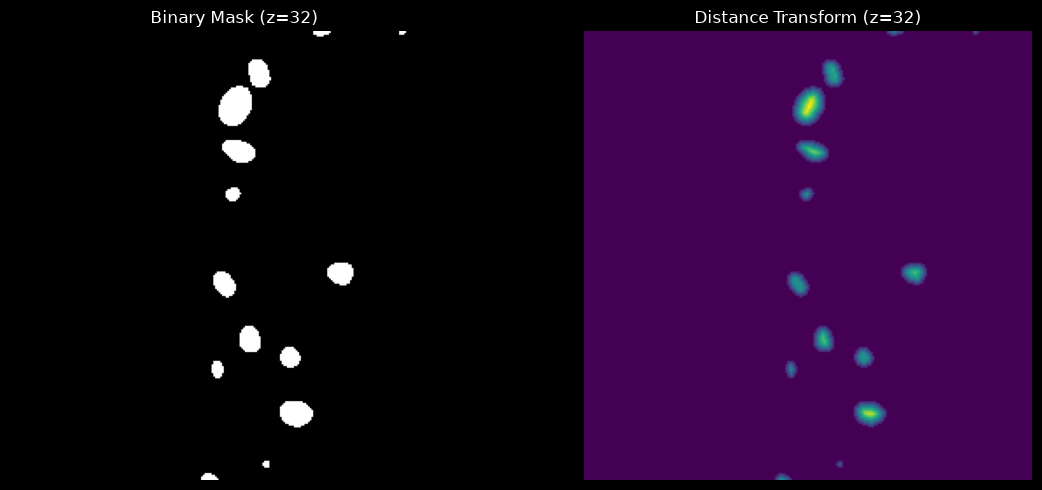

In [32]:
z = distance.shape[0] // 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary_mask[z], cmap="gray")
plt.title(f"Binary Mask (z={z})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(distance[z], cmap="viridis")
plt.title(f"Distance Transform (z={z})")
plt.axis("off")

plt.tight_layout()
plt.show()

Let's project detected cells into 2D space (3D to 2D projection)

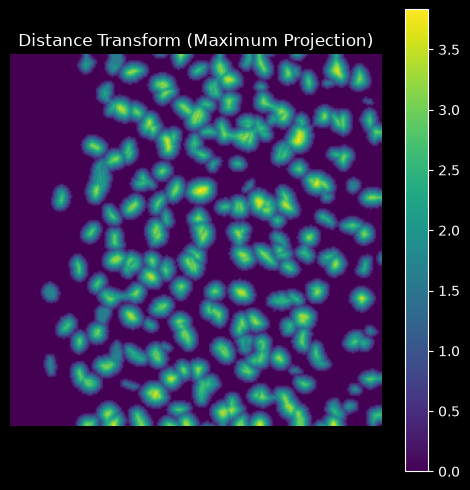

In [33]:
distance_mip = distance.max(axis=0)

plt.figure(figsize=(6, 6))

plt.imshow(distance_mip, cmap="viridis")
plt.title("Distance Transform (Maximum Projection)")
plt.axis("off")

plt.colorbar()

plt.show()

Label connected components

In [34]:
from scipy import ndimage

component_labels, num_components = ndimage.label(binary_mask)

print("Connected components:", num_components)

unique_labels = np.unique(component_labels)

print("Background label:", unique_labels[0])
print("Largest label:", unique_labels[-1])

Connected components: 184
Background label: 0
Largest label: 184


In [35]:
sigma = (
    1.0,   # z
    1.0,   # y
    1.0,   # x
)

distance_smooth = ndimage.gaussian_filter(
    distance,
    sigma=sigma,
)

print(distance_smooth.max())

3.034089830422261


In [36]:
from skimage.morphology import h_maxima

h = 0.5

hmax = h_maxima(
    distance_smooth,
    h=h,
)

In [37]:
markers, num_markers = ndimage.label(hmax)

marker_components = component_labels * (markers > 0)

counts = np.bincount(marker_components.ravel())

next_marker = markers.max() + 1

for component_id in range(1, num_components + 1):

    if counts[component_id] == 0:

        component = component_labels == component_id

        # Highest distance voxel in this component
        peak = np.unravel_index(
            np.argmax(distance_smooth * component),
            component.shape,
        )

        markers[peak] = next_marker
        next_marker += 1

print("Final marker count:", markers.max())

Final marker count: 202


In [42]:
from skimage.segmentation import watershed

instance_labels = watershed(
    -distance_smooth,      # Flood from highest distance values
    markers=markers,       # Our labeled markers
    mask=binary_mask,      # Stay inside foreground
)

print("Number of instances:", instance_labels.max())

Number of instances: 199


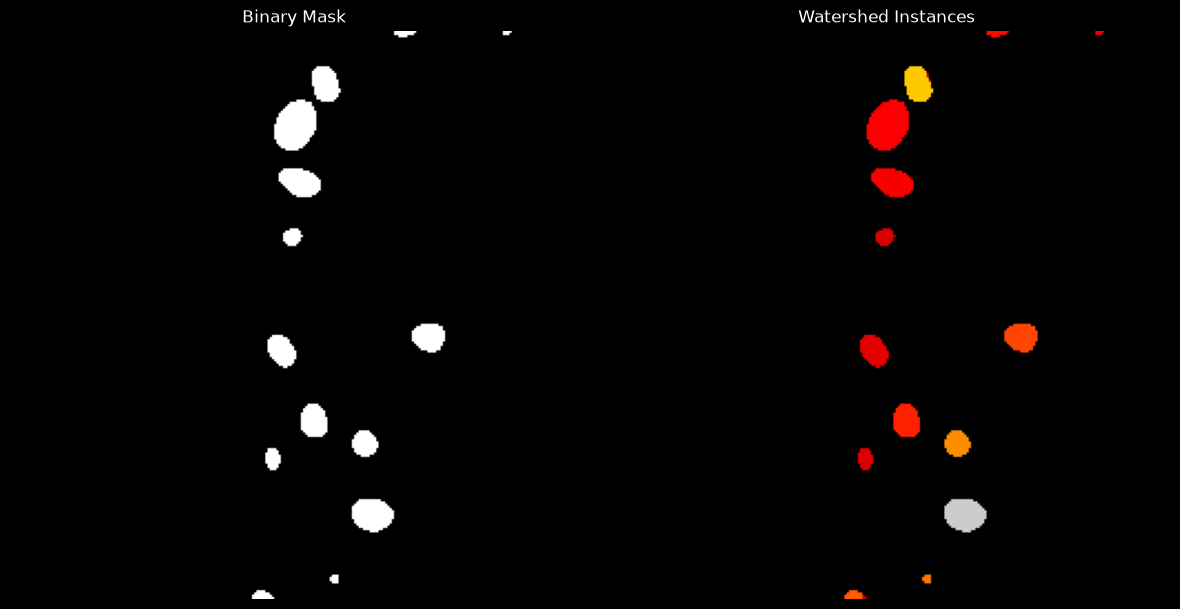

In [43]:
z = instance_labels.shape[0] // 2

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(binary_mask[z], cmap="gray")
ax[0].set_title("Binary Mask")

ax[1].imshow(instance_labels[z], cmap="nipy_spectral")
ax[1].set_title("Watershed Instances")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

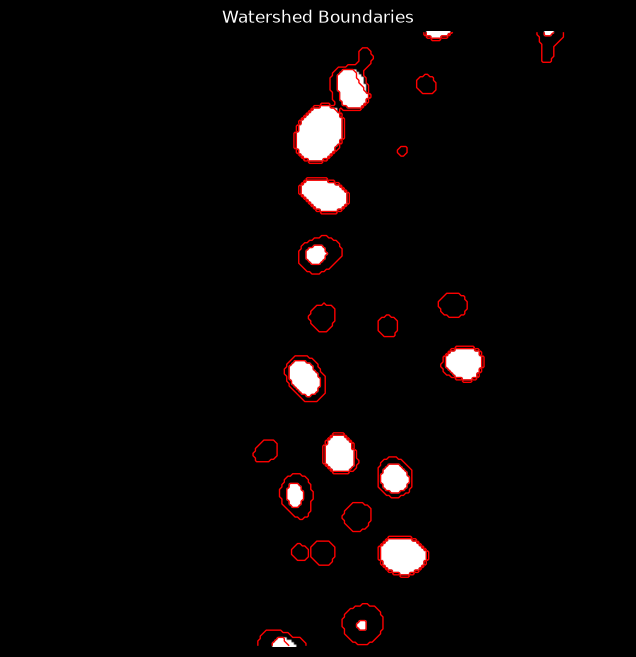

In [45]:
from skimage.segmentation import find_boundaries

z = instance_labels.shape[0] // 2

boundaries = find_boundaries(instance_labels, mode="outer")

plt.figure(figsize=(8, 8))
plt.imshow(binary_mask[z], cmap="gray")
plt.contour(boundaries[z], colors="red", linewidths=1)
plt.title("Watershed Boundaries")
plt.axis("off")
plt.show()

In [46]:
from scipy import ndimage
import numpy as np

labels = np.unique(instance_labels)
labels = labels[labels != 0]

sizes = ndimage.sum(
    np.ones_like(instance_labels),
    labels=instance_labels,
    index=labels,
)

print("Instances :", len(labels))
print("Smallest  :", sizes.min())
print("Largest   :", sizes.max())
print("Median    :", np.median(sizes))
print("Mean      :", np.mean(sizes))

Instances : 199
Smallest  : 52.0
Largest   : 2374.0
Median    : 753.0
Mean      : 762.6130653266332


Save results

In [48]:
from pathlib import Path
import numpy as np

OUTPUT_DIR = Path(
    "../data/sample/processed/stage_4_instance_segmentation"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUTPUT_DIR / "instance_labels.npy", instance_labels)
np.save(OUTPUT_DIR / "markers.npy", markers)

print(f"Saved to {OUTPUT_DIR}")

Saved to ..\data\sample\processed\stage_4_instance_segmentation
